In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

from utility.svm_util import train_and_evaluate_svm
from utility.gcn_util import train_and_evaluate_gcn
import scipy.stats as st

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("fake_reviews_cleaned.csv")
df = df.dropna(subset=['clean_text', 'label']).reset_index(drop=True)

In [3]:
# === RUN EXPERIMENT 5x ===
SEEDS = [1, 11, 22, 33, 44]
svm_results = []
gcn_results = []

svm_probs_list = []
gcn_probs_list = []
y_true_svm_list = []
y_true_gcn_list = []

for seed in SEEDS:
    acc, f1, auc_value, train_time, infer_time, y_true, y_prob = train_and_evaluate_svm(df, seed)
    svm_results.append([acc, f1, auc_value, train_time, infer_time])
    svm_probs_list.append(y_prob)
    y_true_svm_list.append(y_true)

    acc, f1, auc_value, train_time, infer_time, y_true, y_prob = train_and_evaluate_gcn(df, seed)
    gcn_results.append([acc, f1, auc_value, train_time, infer_time])
    gcn_probs_list.append(y_prob)
    y_true_gcn_list.append(y_true)

svm_results = np.array(svm_results)
gcn_results = np.array(gcn_results)

metrics = ["Accuracy", "F1", "AUC", "TrainTime", "InferTime"]

print("\n=== Mean ± Std Over 5 Runs ===")
for i, m in enumerate(metrics):
    print(f"{m}: SVM {svm_results[:,i].mean():.4e} ± {svm_results[:,i].std():.4e} | "
          f"GCN {gcn_results[:,i].mean():.4e} ± {gcn_results[:,i].std():.4e}")

t_stat, p_val = ttest_rel(svm_results[:,0], gcn_results[:,0])
print(f"\nPaired t-test Accuracy p-value = {p_val:.4e}")


=== Mean ± Std Over 5 Runs ===
Accuracy: SVM 8.5482e-01 ± 1.1102e-16 | GCN 8.3899e-01 ± 1.1855e-03
F1: SVM 8.5482e-01 ± 0.0000e+00 | GCN 8.3898e-01 ± 1.1848e-03
AUC: SVM 9.3224e-01 ± 9.7945e-07 | GCN 9.2247e-01 ± 1.0438e-03
TrainTime: SVM 5.2703e+02 ± 5.4287e+01 | GCN 1.2584e+02 ± 2.2867e+01
InferTime: SVM 3.0100e+01 ± 5.2524e+00 | GCN 1.9882e-02 ± 8.5408e-03

Paired t-test Accuracy p-value = 1.1674e-05


In [4]:
# def compute_ci(values, confidence=0.95):
#     values = np.array(values, dtype=float)
#     mean = np.mean(values)
#     std = np.std(values, ddof=1)

#     # Jika variansi nol (semua nilai hasil sama), kembalikan CI = (mean, mean)
#     if std == 0:
#         return mean, mean

#     n = len(values)
#     se = std / np.sqrt(n)
#     t = stats.t.ppf((1 + confidence) / 2, df=n-1)
#     return mean - t * se, mean + t * se

In [5]:
# def ci95(data):
#     return st.t.interval(0.95, len(data)-1, loc=np.mean(data), scale=st.sem(data))

# for i, m in enumerate(metrics):
#     low_svm, high_svm = ci95(svm_results[:, i])
#     low_gcn, high_gcn = ci95(gcn_results[:, i])
#     print(f"{m} 95% CI → SVM [{low_svm:.4f}, {high_svm:.4f}] | GCN [{low_gcn:.4f}, {high_gcn:.4f}]")

In [6]:
#pilih hasil run terbaik berdasarkan f1
best_svm_idx = np.argmax(svm_results[:, 1])   # F1 index
best_gcn_idx = np.argmax(gcn_results[:, 1])

y_true_svm = y_true_svm_list[best_svm_idx]
svm_probs = svm_probs_list[best_svm_idx]

y_true_gcn = y_true_gcn_list[best_gcn_idx]
gcn_probs = gcn_probs_list[best_gcn_idx]

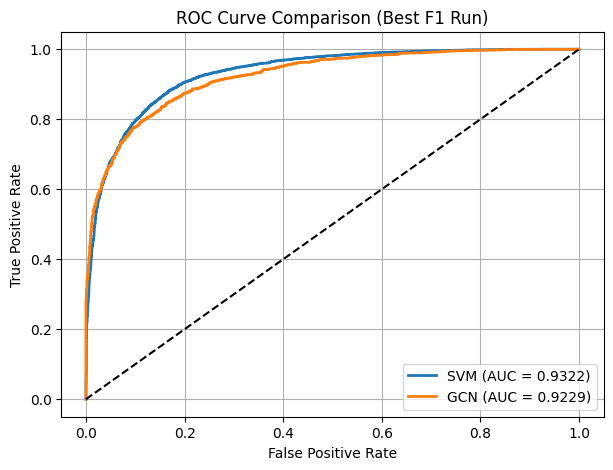

In [7]:
fpr_svm, tpr_svm, _ = roc_curve(y_true_svm, svm_probs)
fpr_gcn, tpr_gcn, _ = roc_curve(y_true_gcn, gcn_probs)

auc_svm = auc(fpr_svm, tpr_svm)
auc_gcn = auc(fpr_gcn, tpr_gcn)

plt.figure(figsize=(7,5))
plt.plot(fpr_svm, tpr_svm, lw=2, label=f"SVM (AUC = {auc_svm:.4f})")
plt.plot(fpr_gcn, tpr_gcn, lw=2, label=f"GCN (AUC = {auc_gcn:.4f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Best F1 Run)")
plt.legend()
plt.grid(True)
plt.show()